# Local Invariant Features
## Computer Vision and Image Processing - Lab Session 5
### Prof: Luigi Di Stefano, luigi.distefano@unibo.it
### Tutor: Alex Costanzino, alex.costanzino@unibo.it - Iacopo Curti, iacopo.curti2@unibo.it

## Correspondences 
A great variety of computer vision problems can be dealt with by finding corresponding points between images. 

**Corresponding (or homologous) points**: image points which are the projection of the same 3D position from different points of view. 

<img src="LabSession5Images/correspondences.png" width="512">

Being projection their appearance can vary greatly between one image and the other so establishing correspondences may be difficult.

## Tasks using Correspondences

### Augmented Reality

<img src="LabSession5Images/AR.png" width="512">

### 3D Reconstruction

<img src="LabSession5Images/3Dreconstruction.png" width="512">

### Mosaicing (a.k.a. panorama photo)

<img src="LabSession5Images/panorama.png" width="512">

### SLAM

<img src="LabSession5Images/slam.png" width="512">

### Visual Search

<img src="LabSession5Images/visual_search.png" width="512">

<!-- ### Object Detection

<img src="LabSession5Images/object_detection.png" width="512"> -->

## Instance Detection

Instance Detection finds instances of objects in images (scenes or targets), given one or more reference images depicting them (models or sources).

<img src="LabSession5Images/object_detection_2.png" width="768">

**What can go wrong? What should a good detection system handle?**

* **Scale invariance**: object in scene may appear at any scale, not only at the same resolution used for the model images;
* **Rotation invariance**: object may appear rotated or skewed in the scene;
* **Photometric invariance**: object may appear in any light condition;
* **Occlusion**: a portion of the objects may not be visible in the scene;
* **Perspective distortion**: the object may appear fairly different if viewed from different camera viewpoint.

## Implement an Instance Detection Pipeline in OpenCV with Local Invariant Features

**Four steps**:
1. **Detection**: identify salient and repeatable points (**keypoints**) in both reference and target images;
2. **Description**: create a unique descriptior for each point, based on its local pixel neighborhood;
3. **Matching**: match points from reference and target images according to a similarity function between the descriptors;
4. **Position Estimation**: estimate the position of the object in the target image given the matching points. 

Let us now try to implement an object detection pipeline. We will use SIFT detector and descriptor in this example.

Let us first import the needed Python libraries:

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

Let us load a train image (scene):

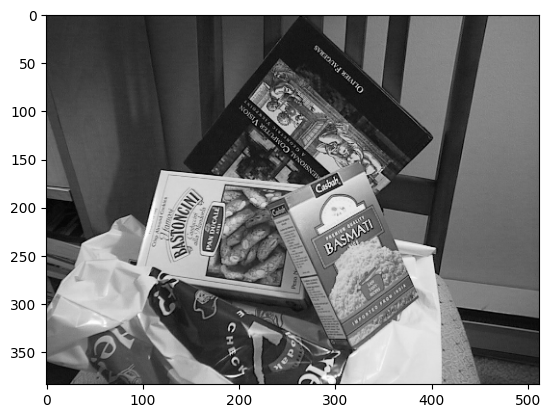

In [2]:
img_train = cv2.imread('LabSession5Images/box_in_scene.png',0) # trainImage
plt.imshow(img_train,cmap='gray',vmin=0,vmax=255)
plt.show()

And a query image (model):

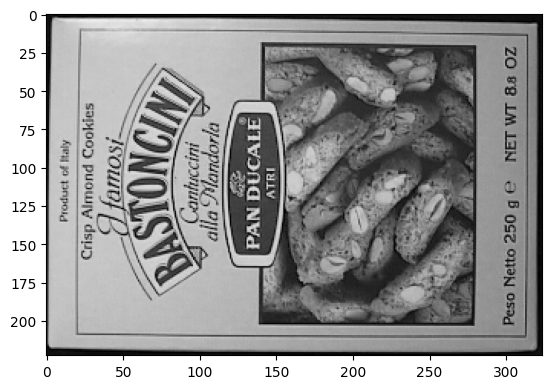

In [3]:
img_query = cv2.imread('LabSession5Images/box.png',0) # queryImage
plt.imshow(img_query,cmap='gray',vmin=0,vmax=255)
plt.show()

### 1. Keypoint Detection

Common schema:

1. Compute a saliency score for each pixel location based on the response to different mathematical operators;
2. Keep only the points that are local maxima;
3. For each keypoint, estimate the scale and orientation at which it is salient (scale and rotation invariance).

Let us now find keypoints in the scene based on the SIFT detector. We first initialise the SIFT detector object in the following way:


In [4]:
# Initiate SIFT detector
sift = cv2.SIFT_create()

Then we need to find keypoints. We will use _detect_ method of the SIFT detector object. Let us find the keypoints of the query image:

In [5]:
# find the keypoints and descriptors with SIFT
kp_query = sift.detect(img_query)

We can print a lot of useful information of a keypoint in the following way:

In [6]:
# Number of keypoints
print(len(kp_query))

# Location of the keypoint
print(kp_query[0].pt)

# Scale
print(kp_query[0].size)

# Rotation
print(kp_query[0].angle)

604
(3.4104702472686768, 216.3043975830078)
2.6696908473968506
278.2254333496094


In case we want to visualize them we can use the following function:

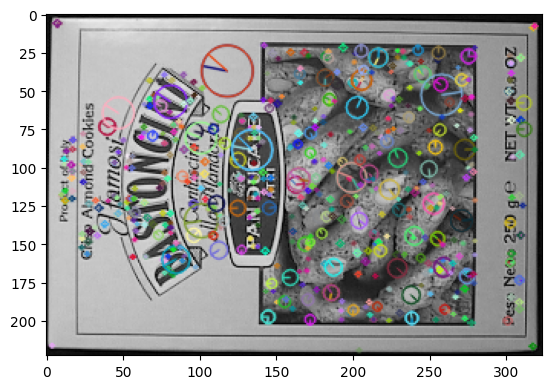

In [7]:
# Visualize keypoints with drawKeypoints.
#Use flag DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS to show scale and orientation of keypoints.
img_visualization = cv2.drawKeypoints(img_query,kp_query,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_visualization)
plt.show()

Now, let us find and draw the keypoints for the train image:

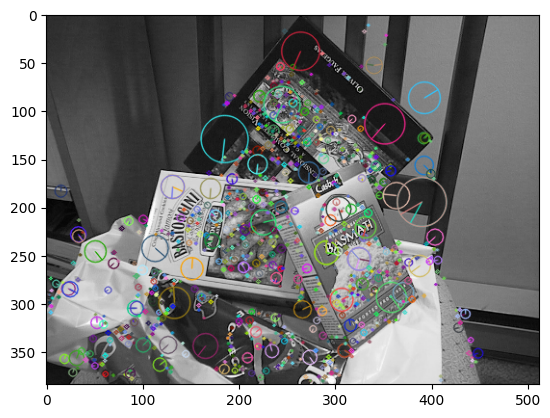

In [8]:
kp_train = sift.detect(img_train)

img=cv2.drawKeypoints(img_train,kp_train,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()

### 2. Keypoints Description 

Compute for each keypoint a unique description usually based on the nearby pixels (descriptor support).

<!-- A good keypoint descriptor should be:
* Repeatable: the descriptions computed at homologus points should be as similar as possible.
* Distinctive: capture the salient informations around the keypoint despite various nuisances (e.g. light changes). 
* Compact: minimize memory occupancy to allow efficient matching.
* Fast: it is usually applied to hundred or thousand of keypoints in each image.

**Given the patch surrounding a keypoint, can we use raw pixel intensities as descriptor?**

Different algorithms provides different descriptions, the common idea is to describe keypoints using an array (histogram) of values that encodes the appearance of its local neighborhood. The size of the support depends on the scale associated to the keypoint (i.e. scale invariance). 
The descriptor are computed according to the orientation associated to the  keypoint (i.e rotation invariance).

The histogram used for the description could be made of:
* floats: more distinctive, high memory footprint 
* bits: less distinctive, small memory footprint (binary descriptors) -->

Some well known algorithms:
1. **SIFT**: 128 floats array (4.096 bytes for each descriptor);
2. **SURF**: 64 floats array (2.048 bytes for each descriptor);
3. **BRISK**:  512 bit array (64 bytes for each descriptor);
4. **ORB**: 256 bit array (32 bytes for each descriptor).

<!-- <img src="LabSession5Images/keypoint_description.png" width="768"> -->

We will use the SIFT descriptor for this sample study. We can use the same SIFT detector object calling the *compute* method:

In [9]:
# Describing keypoints for query and train images
kp_query, des_query = sift.compute(img_query, kp_query)
kp_train, des_train = sift.compute(img_train, kp_train)

For each keypoint we got a a 128 floats array SIFT descriptor:

In [10]:
print("Number of query descriptors: ", len(des_query))
print("Dimensionality of a SIFT descriptor: ", des_query[0].shape)
print("Type of the descriptor: ", des_query[0].dtype)

Number of query descriptors:  604
Dimensionality of a SIFT descriptor:  (128,)
Type of the descriptor:  float32


### 3. Feature Matching

Descriptors extracted from the scene are compared with those extracted from the models to find couples of similar ones. 

**Classic Nearest Neighbour (NN) Search problem**: Given a set of points $n$ points $R=\{r_0,...,r_n\}$, a query point $q$ and a distance function $D$; find the point $r_{nn} \in R$ such that:

$D(q,r_{nn})<D(q,r_k), \forall r_k \in R$

In our scenario, points are feature vectors, and the distance function is Euclidean distance for floats or 
Hamming distance for bits. 

**Naive idea, brute force matcher**: for each keypoint $q$ detected in the scene, compute all the $D(q,r_{nn})$ to find the minimum. Too slow to be applied in a lot of applications, it may sometimes be used with a binary descriptor (the distance function is a simple XOR between the descriptors). 

**Smart idea, indexing technique**: use efficient indexing, such as KD-tree techniques borrowed from database management, to speed up the search.

* Kd-tree - exact
* BBF - approximated
* LSH - for binary descriptor

### 3.1 Fast approximate search in OpenCV 

<!-- <img src="LabSession5Images/kdtree.png" width="512">

One time cost to build the tree, logaritmic number of distances to compute for each $q$.

**Kd-tree** may be thought of as partitioning the space into ‘bins’, during backtracking the bins adjacent to the one containing the found leaf may be examined. 

However the number of bins grow exponentially with the dimension of the space, so kd-tree does not work well for highly dimensional space.

**Features space are highly dimensional!**

<img src="LabSession5Images/kdtree_dimensionality.png" width="512"> -->

**Approximate techniques** help speed up the search.

For instance, we will use an approximate kd-tree algorithm from **FLANN** (Fast Library for Approximate Nearest Neighbours) included in OpenCV. 

**FLANN** contains a collection of algorithms optimised for fast nearest-neighbour search in large datasets and for high-dimensional features.

To implement it in **OpenCV**, we can do the following:

In [11]:
# Defining index for approximate kdtree algorithm
FLANN_INDEX_KDTREE = 1

# Defining parameters for algorithm 
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

# Defining search params.
# checks=50 specifies the number of times the trees in the index should be recursively traversed.
# Higher values gives better precision, but also takes more time
search_params = dict(checks = 50)

# Initializing matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Matching and finding the 2 closest elements for each query descriptor.
matches = flann.knnMatch(des_query,des_train,k=2)

# IMPORTANT: indeed, we are using the knnMatch function, which returns for each query descriptor the k best matches (in our case, k=2)!

### Filtering False Matches in SIFT
To **filter** the matches, Lowe proposed to use a distance ratio test to try to eliminate false matches. 

<!-- The **distance ratio** between the two nearest matches of a considered keypoint is computed and it is a good match when this value is below a threshold. 

Indeed, this ratio allows helping to discriminate between **ambiguous matches** (distance ratio between the two nearest neighbors is close to one) and **well discriminated matches**. 

The figure below from the SIFT paper illustrates the probability that a match is correct based on the nearest-neighbor distance ratio test. -->

<!-- <img src="LabSession5Images/sift_ratio.png" width="512"> -->

In OpenCV, we iterate along all matches, checking the distance ratio between the first and the second closest elements using 0.7 as the distance ratio threshold:

In [12]:
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)

### 4. Position Estimation

**How can we localise the object in the image?**

To localise the object, given the **correspondences** provided by the feature matching process, we can estimate a suitable transformation that brings points from the model image to the instance of the object in the scene. **Because the object is planar**, this transformation is a homography.

**Homography**: a transformation that relates any two images of the same planar surface under the pinhole camera model. A homography is a $3x3$ matrix that transforms points expressed in homogeneous coordinates; it can be decomposed into a rotation, a translation and a perspective distortion.

Given corresponding pairs of pixels $(m,s)$  with $m$ and $s$ belonging to the model and scene images, respectively, estimate a homography means solving a linear over-constrained system by a least square approximation.
To localise the object in the scene image, we may project the four corners of the model image by the homography estimated by the least-squares approach.

**However, as shown below, this may lead to imprecise results:**

<img src="LabSession5Images/bounding_box.png" width="512">

**PROBLEM: some of the match are completely wrong and the estimated homography can be quite bad...**

We can use  **Random Sample Consensus (RANSAC)**, an algorithm to fit a parametric model to noisy data. In our case estimate a homography from good matches while identifying and discarding the wrong ones.

### RANSAC algorithm
Given a set of observation $O=\{o_1...o_n\}$ and a certain parametric model $M$, repeat iteratively:
1. Pick a random (small) subset $I$ of $O$ called inlier set.
2. Fit a model $M_i$ according to the observations in $I$.
3. Test all the other observations against $M_i$, add to a new set $C$ (consensus set) all the observations that fit $M_i$ according to a model specific loss function.
4. If the consensus set is bigger than the one associated with the current best model $M_b$, proceed to step 5, other way return to step 1.
5. Re-compute $M_i$ according to the observations in $I \cup C$, then set $M_b=M_i$. Restart from step 1. 

The procedure is repeated for a fixed amount of steps, and at the end, the best model is returned.

A simple example of RANSAC result used to fit a line to a set of 2D points with Euclidean distance as the loss function:

<img src="LabSession5Images/ransac.gif" width="384">

In our case, we use the homography as a parametric model and the reprojection error as a loss function.

If we compute a bounding box transforming the corner of the model image in the scene image reference system with a homography computed robustly using RANSAC, we obtain the following result:

<img src="LabSession5Images/bounding_box_ransac.png" width="512">


### Implementation in OpenCV

Given the set of good matches, we can perform the following step to find the position of the query object in the scene image:
* We set a condition that at least N matches (defined by MIN_MATCH_COUNT) have to be there to find the object;
* If enough matches are found, we extract the locations of matched keypoints in both images, building correspondence arrays;
* We use the correspondences to robustly estimate a homography with RANSAC;
* Once we get this 3x3 transformation matrix, we use it to transform the corners of the query image to corresponding points in trainImage.

In [13]:
# Checking if we found enough matching
MIN_MATCH_COUNT = 10
if len(good)>MIN_MATCH_COUNT:
    # building the corrspondences arrays of good matches
    src_pts = np.float32([kp_query[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp_train[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    # Using RANSAC to estimate a robust homography. 
    # It returns the homography M and a mask for the discarded points
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    # Mask of undiscarded/discarded points (1/0 values) used in visualization
    matchesMask = mask.ravel().tolist()
    
    # Corners of the query image
    h,w = img_query.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    
    # Projecting the corners into the train image
    dst = cv2.perspectiveTransform(pts,M)
    
    # Drawing the bounding box
    img_train = cv2.polylines(img_train,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print("Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT))
    matchesMask = None

Finally, if we want to draw the matches we can do it in the following way:

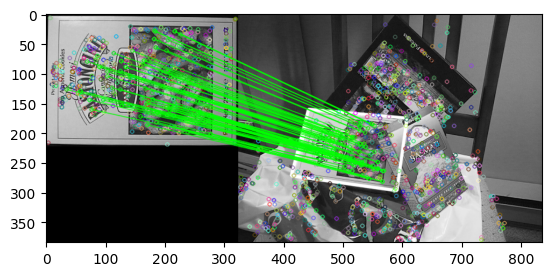

In [ ]:
# Drawing the matches
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None, # not draw keypoints only matching lines
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2) # alias set FLAG cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
img3 = cv2.drawMatches(img_query,kp_query,img_train,kp_train,good,None,**draw_params)
plt.imshow(img3, 'gray')
plt.show()